In [2]:
import logic.pulsed.pulse_objects as po
from logic.pulsed.sampling_functions import SamplingFunctions as SF
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
pjl = pulsedjupyterlogic_AWG #Make sure the Logic is started in the Qudi manager!!!!
import pickle
import datetime
from logic import gwyfile as gwy
import numpy as np
from interface.scanner_interface import ScanStyle, ScannerMode
from hardware.timetagger_counter import HWRecorderMode

###### Helper functions

In [3]:
def prepare_AWG_sequence_mode(pi_pulse, init_res_freq, power, delta_freq, tau_ref, tau_max, max_sweeps_tracking, max_sweeps_T2):
    
    ensemble_list = []
    tau_arr_list = []
    alternating_list = []
    freq_sweep_list = []
    
    pjl.initialize_ensemble(pi_pulse=pi_pulse, LO_freq_0=init_res_freq + 100e6, target_freq_0=init_res_freq, power_0=power, printing = False, upload = False, set_up_measurement = False)
    AWG_ensemble_list, AWG_sequence_step_list, PS_seq_name, tau_arr, alternating, freq_sweep = pjl.Tracking(init_res_freq, delta_freq)
    ensemble_list.append(AWG_ensemble_list[0])
    tau_arr_list.append(tau_arr)
    alternating_list.append(alternating)
    freq_sweep_list.append(freq_sweep)

    AWG_ensemble_list, AWG_sequence_step_list, PS_seq_name, tau_arr, alternating, freq_sweep =pjl.Hecho_alt_phased(tau_ref, tau_ref, 1, name = 'hecho-alt-phased-juptr-ref')
    ensemble_list.append(AWG_ensemble_list[0])
    tau_arr_list.append(tau_arr)
    alternating_list.append(alternating)
    freq_sweep_list.append(freq_sweep)
    
    AWG_ensemble_list, AWG_sequence_step_list, PS_seq_name, tau_arr, alternating, freq_sweep =pjl.Hecho_alt_phased(tau_max, tau_max, 1, name = 'hecho-alt-phased-juptr-sig')
    ensemble_list.append(AWG_ensemble_list[0])
    tau_arr_list.append(tau_arr)
    alternating_list.append(alternating)
    freq_sweep_list.append(freq_sweep)
    
    explicit_steps_list = []
    for idx, name in enumerate(ensemble_list):
        explicit_steps_list.append({"step_index" : idx,
                    "step_segment" : name,
                    "step_loops" : 1,
                    "next_step_index" : idx,
                    "step_end_cond" : 'always'
                    })
    
    sequence_step_list = explicit_steps_list
    pjl.AWG_MW_reset()
    pjl.AWG.load_ready_sequence_mode(sequence_step_list)

    return ensemble_list, tau_arr_list, alternating_list, freq_sweep_list, sequence_step_list

def setup_counter(tau_num, max_sweeps):
    ret_val = afm_scanner_logic._counter.configure_recorder(
                mode=HWRecorderMode.GENERAL_PULSED,
                params={'laser_pulses': tau_num,
                        'bin_width_s': pjl.bin_width,
                        'record_length_s': pjl.read_out_time+pjl.add_tt_read_out,
                        'max_counts': int(max_sweeps)} )

def run_measurement(idx, AWG_ensemble_name, tau_arr, alternating, freq_sweep, res_freq, power, max_sweeps, change_freq = True):
    
    tau_num = len(tau_arr) * 2 if alternating else len(tau_arr)
    setup_counter(tau_num, max_sweeps)

    pjl.AWG.instance.set_sequence_start_step(idx)
        
    if change_freq:
        pjl.mw.set_cw(res_freq + 100e6, power)

    afm_scanner_logic._counter.start_recorder(arm=True)
    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_on()

    pulsed_meas = afm_scanner_logic._counter.get_measurements()[0] # this is the blocking statement

    afm_scanner_logic._pulsed_master_AWG.pulsedmeasurementlogic().pulsegenerator().pulser_off()

    return pulsed_meas

def tracking_analysis(pulsed_ret0, slope2_podmr, prev):
    visibility = (pulsed_ret0[1] - pulsed_ret0[0])/(pulsed_ret0[1] + pulsed_ret0[0])
    new_res_freq =  prev - visibility/slope2_podmr

    return new_res_freq, visibility

def goto(x_pos, y_pos):
    afm_scanner_logic.set_afm_pos({'x':x_pos, 'y':y_pos})


def get_topo(reps=5):
    topo = 0
    for i in range(reps):
        topo = topo + spm.get_sample_pos()['Z']
        time.sleep(0.005)
    return spm.get_sample_scan_range()['Z'] - topo/reps

def go_into_contact():
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_AAP_CTRL'), 1, 0)
    while not spm.is_probe_landed():
        time.sleep(0.001)
    time.sleep(0.5)
        
def do_lift_off(lift_off_height):
    pos = get_pos()
    new_pos = pos - lift_off_height
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_LOOP_ON'), 0, 0)
    spm._dev.base.setParameter(spm._dev.base.getConst('ID_REG_SET_Z_M'), new_pos*1e12, 0)
    

def setup_autoapproach():
    #configuration of autoapproach settings
    # for HFAmpl signal
    threshold = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_SETP_DISP')) / 1e7
    spm._dev.aap.setAApThreshold(threshold)

    # dF     8
    # HFAmpl       13
    input_signal = spm._dev.base.getParameter(spm._dev.base.getConst('ID_REG_INPUT'))
    threshold_cond = 1 if input_signal==13 else 0        
    spm._dev.aap.setAApStopCondition(threshold_cond) # [0, 1] >threshold/<threshold
    spm._dev.aap.setAApStepsPerApproach(0)

    spm._dev.aap.setAApAproachMode(1) # [0, 1] Ramp/Loop
    spm._dev.aap.setAApModeAfter(0) # [0, 1, 2] On/Retract/Off

def add_usual(meas_dict, name, xy_units, si_units, nice_name, scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y ):
    meas_dict[name]['coord0_arr'] = scan_array_x
    meas_dict[name]['coord1_arr'] = scan_array_y
    meas_dict[name]['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    meas_dict[name]['xy_units'] = xy_units
    meas_dict[name]['si_units'] = si_units
    meas_dict[name]['nice_name'] = nice_name
    return meas_dict
    
def measurement_loop(scan_origin_x, scan_range_x, scan_step_x, scan_origin_y, scan_range_y, scan_step_y, rotation, 
                     afm_int_time, afm_scan_speed, liftoff_mode, liftoff_height, tip_oscillation_off, turn_off_wait, 
                     turn_on_wait, power, pi_pulse, init_res_freq, delta_freq, slope, tracking_repetitions, 
                     max_sweeps_tracking, max_sweeps_T2, tau_max, tau_ref, path):
    
    afm_scanner_logic.jupyter_meas_stop = False
    afm_scanner_logic.jupyter_meas_pause = False
    
    scan_start_x = scan_origin_x-scan_range_x/2
    scan_stop_x = scan_origin_x+scan_range_x/2
    scan_start_y = scan_origin_y-scan_range_y/2
    scan_stop_y = scan_origin_y+scan_range_y/2

    scan_arr = afm_scanner_logic.create_scan_array(scan_origin_x, scan_range_x, scan_step_x,
                                    scan_origin_y, scan_range_y,
                                    scan_step_y, rotation)

    point_grid_dict = afm_scanner_logic.create_point_grid_dict(scan_arr)
    
#     Set up the SPM device for performing a scan in path mode
    spm.configure_scanner(mode=ScannerMode.PROBE_CONTACT,
                                                            params= {'line_points': scan_step_x,
                                                                     'lines_num': scan_step_y},
                                                            scan_style=ScanStyle.POINT)
    
    spm.configure_area_new(point_grid_dict, scan_arr,
                                     afm_int_time=afm_int_time,
                                     afm_scan_speed=afm_scan_speed,
                                     liftoff_mode=liftoff_mode,
                                     liftoff_height=liftoff_height)
    
    scan_array_x = np.linspace(scan_start_x, scan_stop_x, scan_step_x)
    scan_array_y = np.linspace(scan_start_y, scan_stop_y, scan_step_y)
    
    #Deactivate the printing of information into the manager log as this is time intensive
    awg_spectrum.print_log_info = False
    sequencegeneratorlogic_AWG.print_log_info = False
    sequencegeneratorlogic.print_log_info = False
    
    #Create needed sequences for the pulsestremaer and the AWG
    ensemble_list, tau_arr_list, alternating_list, freq_sweep_list, sequence_step_list = prepare_AWG_sequence_mode(pi_pulse, init_res_freq, power, delta_freq, tau_ref, tau_max, max_sweeps_tracking, max_sweeps_T2)

    analysis_settings = afm_scanner_logic._podmr.pulsed_analysis_settings

    topography = np.zeros((scan_step_y,scan_step_x))
    counts = np.zeros((scan_step_y,scan_step_x))
    tracking_raw = np.zeros((scan_step_y,scan_step_x,2,int((pjl.read_out_time+pjl.add_tt_read_out)/pjl.bin_width)))
    res_freq = np.zeros((scan_step_y,scan_step_x))
    T2_ref = np.ones((scan_step_y,scan_step_x))
    T2_ref_raw = np.zeros((scan_step_y,scan_step_x,2,int((pjl.read_out_time+pjl.add_tt_read_out)/pjl.bin_width)))
    T2_sig = np.zeros((scan_step_y,scan_step_x))
    T2_sig_raw = np.zeros((scan_step_y,scan_step_x,2,int((pjl.read_out_time+pjl.add_tt_read_out)/pjl.bin_width)))

    
    if tip_oscillation_off:
        T2_ref_static = np.ones((scan_step_y,scan_step_x))
        T2_ref_raw_static = np.zeros((scan_step_y,scan_step_x,2,int((pjl.read_out_time+pjl.add_tt_read_out)/pjl.bin_width)))
        T2_sig_static = np.zeros((scan_step_y,scan_step_x))
        T2_sig_raw_static = np.zeros((scan_step_y,scan_step_x,2,int((pjl.read_out_time+pjl.add_tt_read_out)/pjl.bin_width)))

    start_time = datetime.datetime.now()
    
    meas_dict = {}

    meas_dict = {'params': {'Parameters for': 'Resonance tracking and fast Hahn Echo scan'}}
    meas_dict['params']['axis name for coord0'] = 'X'
    meas_dict['params']['axis name for coord1'] = 'Y'
    meas_dict['params']['coord0_start (m)'] = scan_start_x
    meas_dict['params']['coord0_stop (m)'] = scan_stop_x
    meas_dict['params']['coord0_num (#)'] = scan_step_x
    meas_dict['params']['coord1_start (m)'] = scan_start_y
    meas_dict['params']['coord1_stop (m)'] = scan_stop_y
    meas_dict['params']['coord1_num (#)'] = scan_step_y

    meas_dict['params']['MW power (dBm)'] = power_0
    meas_dict['params']['Pi pulse Duration (s)'] = pi_pulse
    meas_dict['params']['Initial resonance frequency (Hz)'] = init_res_freq
    meas_dict['params']['Delta_0 (Hz)'] = delta_freq
    meas_dict['params']['Slope (a.u.)'] = slope
    meas_dict['params']['Tracking repetitions (#)'] = tracking_repetitions
    meas_dict['params']['Hahn Echo waiting time (s)'] = tau_max
    meas_dict['params']['Measurement runs tracking (#)'] = max_sweeps_tracking
    meas_dict['params']['Measurement runs T2 (#)'] = max_sweeps_T2
    
    meas_dict['params']['Lift-off mode'] = liftoff_mode
    meas_dict['params']['Lift-off height (m)'] = liftoff_height
    meas_dict['params']['Tip oscillation OFF'] = tip_oscillation_off
    meas_dict['params']['Tip oscillation turning OFF waiting time (s)'] =turn_off_wait
    meas_dict['params']['Tip oscillation turning ON waiting time (s)'] =turn_on_wait

    meas_dict['params']['Measurement start'] = start_time.isoformat('_','seconds')
    meas_dict['params']['Measurement stop'] = datetime.datetime.now().isoformat('_','seconds')

    meas_dict.update({'topo': {'data': topography}})
    meas_dict = add_usual(meas_dict, 'topo', 'm', 'm','Topography', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    
    meas_dict.update({'counts': {'data': counts}})
    meas_dict = add_usual(meas_dict, 'counts', 'm', 'c/s','Fluorescence', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )

    meas_dict.update({'tracking_raw': {'data': tracking_raw}})
    meas_dict = add_usual(meas_dict, 'tracking_raw', 'm', 'a.u.','Tracking raw', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )

    meas_dict.update({'res_freq': {'data': res_freq}})
    meas_dict = add_usual(meas_dict, 'res_freq', 'm', 'Hz','Resonance frequency', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )

    meas_dict.update({'T2_ref': {'data': T2_ref}})
    meas_dict = add_usual(meas_dict, 'T2_ref', 'm', 'a.u.','T2 reference', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    meas_dict['T2_ref']['coord2_arr'] = tau_arr_list[1]
    
    meas_dict.update({'T2_ref_raw': {'data': T2_ref_raw}})
    meas_dict = add_usual(meas_dict, 'T2_ref_raw', 'm', 'a.u.','T2 reference raw', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    meas_dict['T2_ref_raw']['coord2_arr'] = tau_arr_list[1]
    
    meas_dict.update({'T2_sig': {'data': T2_sig}})
    meas_dict = add_usual(meas_dict, 'T2_sig', 'm', 'a.u.','T2 signal', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    meas_dict['T2_sig']['coord2_arr'] = tau_arr_list[2]
    
    meas_dict.update({'T2_sig_raw': {'data': T2_sig_raw}})
    meas_dict = add_usual(meas_dict, 'T2_sig_raw', 'm', 'a.u.','T2 signal raw', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    meas_dict['T2_sig_raw']['coord2_arr'] = tau_arr_list[2]
    
    meas_dict.update({'T2_sig_corr': {'data': T2_sig/T2_ref}})
    meas_dict = add_usual(meas_dict, 'T2_sig_corr', 'm', 'a.u.','T2 signal corrected', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
    
    if tip_oscillation_off:
        meas_dict.update({'T2_ref_static': {'data': T2_ref_static}})
        meas_dict = add_usual(meas_dict, 'T2_ref_static', 'm', 'a.u.','T2 reference_static', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
        meas_dict['T2_ref_static']['coord2_arr'] = tau_arr_list[1]

        meas_dict.update({'T2_ref_raw_static': {'data': T2_ref_raw_static}})
        meas_dict = add_usual(meas_dict, 'T2_ref_raw_static', 'm', 'a.u.','T2 reference raw_static', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
        meas_dict['T2_ref_raw_static']['coord2_arr'] = tau_arr_list[1]

        meas_dict.update({'T2_sig_static': {'data': T2_sig_static}})
        meas_dict = add_usual(meas_dict, 'T2_sig_static', 'm', 'a.u.','T2 signal_static', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
        meas_dict['T2_sig_static']['coord2_arr'] = tau_arr_list[2]

        meas_dict.update({'T2_sig_raw_static': {'data': T2_sig_raw_static}})
        meas_dict = add_usual(meas_dict, 'T2_sig_raw_static', 'm', 'a.u.','T2 signal raw_static', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )
        meas_dict['T2_sig_raw_static']['coord2_arr'] = tau_arr_list[2]

        meas_dict.update({'T2_sig_corr_static': {'data': T2_sig_static/T2_ref_static}})
        meas_dict = add_usual(meas_dict, 'T2_sig_corr_static', 'm', 'a.u.','T2 signal corrected_static', scan_array_x, scan_array_y, scan_start_x, scan_stop_x, scan_start_y, scan_stop_y )

    #additional dictonary for imaging of the running scan in qudi SPM
    #Topo -> Height(Dac)_fw
    #Counts -> counts_fw
    #Tracked resonance -> fit_param_fw
    #T2 reference (ODMR contrast) -> fit_param_bw
    #T2 signal corrected -> b_field_fw
    image_dict = {}
    
    image_dict.update({'Height(Dac)_fw': {'data': topography}})
    image_dict['Height(Dac)_fw']['coord0_arr'] = scan_array_x
    image_dict['Height(Dac)_fw']['coord1_arr'] = scan_array_y
    image_dict['Height(Dac)_fw']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    image_dict['Height(Dac)_fw']['xy_units'] = 'm'
    image_dict['Height(Dac)_fw']['si_units'] = 'm'
    image_dict['Height(Dac)_fw']['nice_name'] = 'Topography'
    image_dict['Height(Dac)_fw']['scale_fac'] = 1e-6
    image_dict['Height(Dac)_fw']['measured_units'] = 'µm'
    image_dict['Height(Dac)_fw']['display_range'] = None
    image_dict['Height(Dac)_fw']['corr_plane_coeff'] = [0.0, 0.0, 0.0] 
    image_dict['Height(Dac)_fw']['image_correction'] = False
    qafm_gui.update_dockwidget_visibility(True, 'Height(Dac)_fw')
    
    image_dict.update({'counts_fw': {'data': counts}})
    image_dict['counts_fw']['coord0_arr'] = scan_array_x
    image_dict['counts_fw']['coord1_arr'] = scan_array_y
    image_dict['counts_fw']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    image_dict['counts_fw']['xy_units'] = 'm'
    image_dict['counts_fw']['si_units'] = 'c/s'
    image_dict['counts_fw']['nice_name'] = 'Fluorescence'
    image_dict['counts_fw']['scale_fac'] = 1
    image_dict['counts_fw']['measured_units'] = 'c/s'
    image_dict['counts_fw']['display_range'] = None
    image_dict['counts_fw']['corr_plane_coeff'] = [0.0, 0.0, 0.0] 
    image_dict['counts_fw']['image_correction'] = False
    qafm_gui.update_dockwidget_visibility(True, 'counts_fw')
    
    image_dict.update({'fit_param_fw': {'data': res_freq}})
    image_dict['fit_param_fw']['coord0_arr'] = scan_array_x
    image_dict['fit_param_fw']['coord1_arr'] = scan_array_y
    image_dict['fit_param_fw']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    image_dict['fit_param_fw']['xy_units'] = 'm'
    image_dict['fit_param_fw']['si_units'] = 'Hz'
    image_dict['fit_param_fw']['nice_name'] = 'Tracked resonance'
    image_dict['fit_param_fw']['scale_fac'] = 1e9
    image_dict['fit_param_fw']['measured_units'] = 'GHz'
    image_dict['fit_param_fw']['display_range'] = None
    image_dict['fit_param_fw']['corr_plane_coeff'] = [0.0, 0.0, 0.0] 
    image_dict['fit_param_fw']['image_correction'] = False
    qafm_gui.update_dockwidget_visibility(True, 'fit_param_fw')
    
    image_dict.update({'fit_param_bw': {'data': T2_ref}})
    image_dict['fit_param_bw']['coord0_arr'] = scan_array_x
    image_dict['fit_param_bw']['coord1_arr'] = scan_array_y
    image_dict['fit_param_bw']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    image_dict['fit_param_bw']['xy_units'] = 'm'
    image_dict['fit_param_bw']['si_units'] = 'a.u.'
    image_dict['fit_param_bw']['nice_name'] = 'T2 reference signal (ODMR contrast)'
    image_dict['fit_param_bw']['scale_fac'] = 1
    image_dict['fit_param_bw']['measured_units'] = 'a.u.'
    image_dict['fit_param_bw']['display_range'] = None
    image_dict['fit_param_bw']['corr_plane_coeff'] = [0.0, 0.0, 0.0] 
    image_dict['fit_param_bw']['image_correction'] = False
    qafm_gui.update_dockwidget_visibility(True, 'fit_param_bw')
    
    image_dict.update({'b_field_fw': {'data': T2_sig/T2_ref}})
    image_dict['b_field_fw']['coord0_arr'] = scan_array_x
    image_dict['b_field_fw']['coord1_arr'] = scan_array_y
    image_dict['b_field_fw']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
    image_dict['b_field_fw']['xy_units'] = 'm'
    image_dict['b_field_fw']['si_units'] = 'a.u.'
    image_dict['b_field_fw']['nice_name'] = 'Corrected T2 signal'
    image_dict['b_field_fw']['scale_fac'] = 1
    image_dict['b_field_fw']['measured_units'] = 'a.u.'
    image_dict['b_field_fw']['display_range'] = None
    image_dict['b_field_fw']['corr_plane_coeff'] = [0.0, 0.0, 0.0] 
    image_dict['b_field_fw']['image_correction'] = False
    qafm_gui.update_dockwidget_visibility(True, 'b_field_fw')
    
    #prepare spm qudi for the measurement
    afm_scanner_logic._qafm_scan_array = image_dict
    qafm_gui.adjust_qafm_image()
    
    TF_Amp = spm._dev.afm.getTFExcitationAmplitude()
    
    for idy in tqdm(range(scan_step_y)):
        for idx in range(scan_step_x):
            
            #Pause measurement if true
            while afm_scanner_logic.jupyter_meas_pause:
                time.sleep(0.5)
                
            #Move to new pixel position
            #Measure Topography
            topography[idy,idx] = spm.scan_point()
        
            counts_list = []
            #Measure resonance frequency with tracking mode
            change_freq = False
            if idx == 0 and idy != 0:
                res_freq_used = res_freq[idy-1,idx]
                change_freq = True
            
            elif idx == 0 and idy == 0:
                res_freq_used = init_res_freq
                change_freq = True
            
            for i in range(tracking_repetitions):
                index = 0
                tracking_raw[idy, idx] = run_measurement(index, ensemble_list[index], tau_arr_list[index], alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_tracking, change_freq = change_freq)
                pulsed_ret0, pulsed_ret1, ref_data, ref_time = afm_scanner_logic.analyse_pulsed_meas(analysis_settings, tracking_raw[idy, idx], alternating_list[index], False, True)
                counts_list.append(np.mean(ref_data)/ref_time/max_sweeps_tracking)
                res_freq[idy, idx], vis = tracking_analysis(pulsed_ret0, slope, res_freq_used)
                res_freq_used = res_freq[idy, idx]
                change_freq = True
            
            #Measure T2 reference signal C0
            index = 1
            T2_ref_raw[idy, idx] = run_measurement(index, ensemble_list[index], tau_arr_list[index], alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_T2, change_freq = True)
            pulsed_ret0, pulsed_ret1, ref_data, ref_time = afm_scanner_logic.analyse_pulsed_meas(analysis_settings, T2_ref_raw[idy, idx], alternating_list[index], False, False)
            T2_ref[idy, idx] = pulsed_ret0[0]-pulsed_ret0[1]
            counts_list.append(np.mean(ref_data[0])/ref_time[0]/max_sweeps_T2)
            counts_list.append(np.mean(ref_data[1])/ref_time[1]/max_sweeps_T2)
            
            #Measure T2 signal CS
            index = 2
            T2_sig_raw[idy, idx] = run_measurement(index, ensemble_list[index], tau_arr_list[index], alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_T2, change_freq = False)
            pulsed_ret0, pulsed_ret1, ref_data, ref_time = afm_scanner_logic.analyse_pulsed_meas(analysis_settings, T2_sig_raw[idy, idx], alternating_list[index], False, False)
            T2_sig[idy, idx] = pulsed_ret0[0]-pulsed_ret0[1]
            counts_list.append(np.mean(ref_data[0])/ref_time[0]/max_sweeps_T2)
            counts_list.append(np.mean(ref_data[1])/ref_time[1]/max_sweeps_T2)
            
            if tip_oscillation_off and liftoff_mode:
                spm._dev.afm.setTFExcitationAmplitude(0)
                time.sleep(turn_off_wait)
                
                #Measure T2 reference signal C0
                index = 1
                T2_ref_raw_static[idy, idx] = run_measurement(index, ensemble_list[index], tau_arr_list[index], alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_T2, change_freq = True)
                pulsed_ret0, pulsed_ret1, ref_data, ref_time = afm_scanner_logic.analyse_pulsed_meas(analysis_settings, T2_ref_raw_static[idy, idx], alternating_list[index], False, False)
                T2_ref_static[idy, idx] = pulsed_ret0[0]-pulsed_ret0[1]
                counts_list.append(np.mean(ref_data[0])/ref_time[0]/max_sweeps_T2)
                counts_list.append(np.mean(ref_data[1])/ref_time[1]/max_sweeps_T2)

                #Measure T2 signal CS
                index = 2
                T2_sig_raw_static[idy, idx] = run_measurement(index, ensemble_list[index], tau_arr_list[index], alternating_list[index], freq_sweep_list[index], res_freq_used, power, max_sweeps_T2, change_freq = True)
                pulsed_ret0, pulsed_ret1, ref_data, ref_time = afm_scanner_logic.analyse_pulsed_meas(analysis_settings, T2_sig_raw_static[idy, idx], alternating_list[index], False, False)             
                T2_sig_static[idy, idx] = pulsed_ret0[0]-pulsed_ret0[1]
                counts_list.append(np.mean(ref_data[0])/ref_time[0]/max_sweeps_T2)
                counts_list.append(np.mean(ref_data[1])/ref_time[1]/max_sweeps_T2)

                spm._dev.afm.setTFExcitationAmplitude(TF_Amp)
                time.sleep(turn_on_wait)

            counts[idy, idx] = np.mean(counts_list)
            
            spm.scan_point(move_along=True)

            #Update image in qudi spm modul
            image_dict['Height(Dac)_fw']['data'] = topography
            image_dict['counts_fw']['data'] = counts
            image_dict['fit_param_fw']['data'] = res_freq
            image_dict['fit_param_bw']['data'] = T2_ref
            image_dict['b_field_fw']['data'] = T2_sig/T2_ref
            
            afm_scanner_logic._qafm_scan_array = image_dict
            afm_scanner_logic.sigQAFMLineScanFinished.emit()
            
            if afm_scanner_logic.jupyter_meas_stop:
                break
                
        #run save routine end of every fast axis loop

        meas_dict['topo']['data'] = topography
        meas_dict['counts']['data'] = counts
        meas_dict['res_freq']['data'] = res_freq
        meas_dict['tracking_raw']['data'] = res_freq
        meas_dict['T2_ref']['data'] = T2_ref
        meas_dict['T2_ref_raw']['data'] = T2_ref_raw
        meas_dict['T2_sig']['data'] = T2_sig
        meas_dict['T2_sig_raw']['data'] = T2_sig_raw
        meas_dict['T2_sig_corr']['data'] = T2_sig/T2_ref
        
        if tip_oscillation_off:
            meas_dict['T2_ref_static']['data'] = T2_ref_static
            meas_dict['T2_ref_raw_static']['data'] = T2_ref_raw_static
            meas_dict['T2_sig_static']['data'] = T2_sig_static
            meas_dict['T2_sig_raw_static']['data'] = T2_sig_raw_static
            meas_dict['T2_sig_corr_static']['data'] = T2_sig_static/T2_ref_static

        #write temporary file fro gwyddion here
        with open(path+'.pickle', 'wb') as f:
            pickle.dump(meas_dict, f)

        save_obj_to_gwyddion(dataobj=meas_dict,filename=path+'.gwy')
        
        if afm_scanner_logic.jupyter_meas_stop:
            print('Measurement force stopped')
            break
    
    #Activate the printing of information into the manager log again
    awg_spectrum.print_log_info = True
    sequencegeneratorlogic_AWG.print_log_info = True
    sequencegeneratorlogic.print_log_info = True
    awg_spectrum.pulser_off()
    mw_source_smbv.off()
    mw_source_sgs.off()
    afm_scanner_logic._spm.finish_scan(retract=retract)
    
    return meas_dict

def save_obj_to_gwyddion(dataobj,filename,gwytypes=['image']):
    """save_obj_to_gwyddion(): writes qudi data object to Gwyddion file
        input:  
        - dataobj: proteusQ data object of from dataobj['data_key']
        - filename: file path to save object
        - prefix:  name to be prefixed to all head objects

        requirements:
        dataobj['scan_type'] must contain keys {coord0[], coord1[], data[,], params[coord0-1_start-stop], si_units, nice_name}
    """

    # check for existance of valid object names
    datakeys = list(dataobj.keys())

    # overall object container
    objout = gwy.objects.GwyContainer()

    for dataki,datak in enumerate(sorted(datakeys, key=str.lower)):
        meas = dataobj[datak]

        # check that data is valid
        if not {'coord0_arr','coord1_arr','data'}.issubset(set(meas.keys())):
            continue 

        # check that there is non-trivial data (skip empty measurements)
        if np.sum(meas['data']) == 0.0:
            continue

        # transform data
        #scalefactor = meas['scale_fac']
        coord0 = meas['coord0_arr']
        coord1 = meas['coord1_arr']
        data_si = meas['data'] #* scalefactor
        if len(data_si.shape) != 2:
            continue

        params = meas['params']
        coord0_start = next(k for k in params.keys() if k.startswith('coord0_start'))
        coord0_stop = next(k for k in params.keys() if k.startswith('coord0_stop'))
        coord1_start = next(k for k in params.keys() if k.startswith('coord1_start'))
        coord1_stop = next(k for k in params.keys() if k.startswith('coord1_stop'))

        xy_units = meas['xy_units']
        z_units = meas['si_units']
        measname = datak + ":" + meas['nice_name']

        # encode to image
        img = gwy.objects.GwyDataField(data=data_si, si_unit_xy=xy_units, si_unit_z=z_units)
        img.xoff = params[coord0_start]
        img.xreal = params[coord0_stop] - params[coord0_start]
        img.yoff = params[coord1_start]
        img.yreal = params[coord1_stop] - params[coord1_start]

        # add to parent object 
        if 'image' in gwytypes: 
            # image types
            basekey = '/' + str(dataki) + '/data'
            objout[basekey + '/title'] = measname
            objout['/' + str(dataki) + '/base/palette'] = 'Sky'
            objout[basekey] = img
            # comment meta data
            if meas['params']:
                d = {key: str(val) for key, val in meas['params'].items()}
                meta = gwy.objects.GwyContainer(d)
                objout['/' + str(dataki) + '/meta'] = meta

    # write out file    
    if objout:
        objout.tofile(filename)

###### Measurement parameters

In [4]:
#measurement parameters
pi_pulse = 100e-9

#Driving information for the first LO (SGS)
target_freq_0 = 1.14597e9 #initial resonance frequency
power_0 = -20

#Information for running tracking mode
tracking_repetitions = 1
delta_freq = 5.5e6
slope = afm_scanner_logic._podmr.vis_slope

max_sweeps_tracking =150e3 #Number of sweeps for tracking pulsed measurements
max_sweeps_T2 =400e3 #Number of sweeps for T2 related pulsed measurements

#Information for running the fast Hahn Echo measurement
tau_ref = pi_pulse + 1e-9
tau_max = 2.1e-6

#Scan area
scan_origin_x=3e-6
scan_range_x=2e-6
scan_step_x=100

scan_origin_y=3e-6 
scan_range_y=2e-6
scan_step_y=100

rotation = 0

afm_int_time = 4e-3
afm_scan_speed = 500e-9

liftoff_mode = False
liftoff_height = 5e-9

#Define, whether the tip oscillation is turned of during lift off. The messurement is taken with tip oscillation on and off
tip_oscillation_off = False
turn_off_wait = 2
turn_on_wait = 0.2

retract = True

#additional information for save tag
tip_name = 'A-F17-26'
sample = 'NbTiN_Paris_S1'
temperature = '3.0K'
b_field = '70mT_Bnv_sFC'
contact = 'IC'
extra = ''

afm_scanner_logic.jupyter_meas_stop = False
afm_scanner_logic.jupyter_meas_pause = False

######  Run measurement

In [5]:
afm_scanner_logic.jupyter_meas_stop = False
afm_scanner_logic.jupyter_meas_pause = False

string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Tracking_plus_fast_T2_scan_TEMP'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module('AttoDRY2200_Pi3_SPM\\')

data_array = measurement_loop(scan_origin_x, scan_range_x, scan_step_x, scan_origin_y, scan_range_y, scan_step_y, rotation, afm_int_time, afm_scan_speed, liftoff_mode, liftoff_height, tip_oscillation_off, turn_off_wait, turn_on_wait, power_0, pi_pulse, target_freq_0, delta_freq, slope, tracking_repetitions, max_sweeps_tracking, max_sweeps_T2, tau_max, tau_ref, filepath+filename)

######################
string = datetime.datetime.now().isoformat('_','seconds')+'_'+'Tracking_plus_fast_T2_scan'+'_'+tip_name+'_'+sample+'_'+temperature+'_'+b_field+'_'+contact+'_'+extra
filename = string.replace(':','-')
filepath = savelogic.get_path_for_module('AttoDRY2200_Pi3_SPM\\')

with open(filepath+filename+'.pickle', 'wb') as f:
    pickle.dump(data_array, f)
    
save_obj_to_gwyddion(dataobj=data_array,filename=filepath+filename+'.gwy')

  7%|#####5                                                                         | 7/100 [1:26:43<19:13:43, 744.34s/it]

Measurement force stopped


  7%|#####5                                                                         | 7/100 [1:36:41<21:24:38, 828.80s/it]


######  Grab the data from the pickel

In [5]:
filebeginning = '2025-01-16_19-31-57_Tracking_plus_fast_T2_scan_A-F17-26_NbSe2_S6_2.0K_70mT_Bnv_sFC_IC_tip_osc_on_and_off' #here the beginning of the filename, including the date and sample name, is needed

file_year = filebeginning[0:4]
file_month = filebeginning[5:7]
file_day = filebeginning[8:10]
path = 'G:\\Data\\Qudi_Data\\'+file_year+'\\'+file_month+'\\'+file_year+file_month+file_day+'\\AttoDRY2200_Pi3_SPM\\'
filepath = path + filebeginning

In [6]:
with open(filepath+'.pickle', 'rb') as f:
    data_array = pickle.load(f)

######  Calculate Bias field and stray field

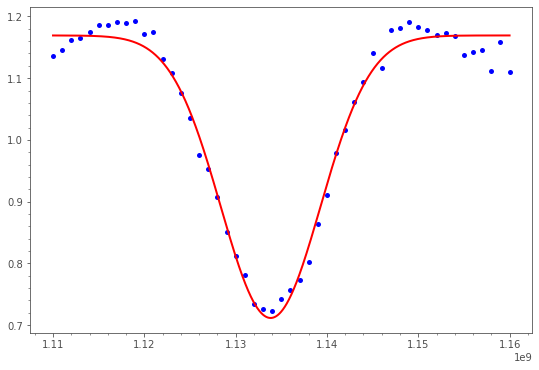

Bias field:  0.062363208085598545 T
FWHM:  12.84385445273004 MHz
Contrast:  39.145333071626496 %


In [7]:
#Analyse bias field
#Gathering data from dictonary
podrm_file = '20250114-1647-38_A-F17-26_NbSe2_S6_2K_70mT_Bnv_OOC_ODMR_data_ch0_range0'+'.dat'

podmr_file_year = podrm_file[0:4]
podmr_file_month = podrm_file[4:6]
podmr_file_day = podrm_file[6:8]
podmr_path = 'G:\\Data\\Qudi_Data\\'+podmr_file_year+'\\'+podmr_file_month+'\\'+podmr_file_year+podmr_file_month+podmr_file_day+'\\PODMR\\'
podmr_filepath = podmr_path + podrm_file
data_raw = np.loadtxt(podmr_filepath).T

var_list,data = (data_raw[0],data_raw[1])

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

mode = 'gaussian_dip'
gslac = False
left = False

fwhm_bias = 0
contrast_bias = 0

#Determine fit

if mode == 'double':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_dip)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N15':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N15)
    lm,_ = fitlogic.make_lorentziandouble_model()
    
elif mode == 'N14':
    fit = afm_scanner_logic._fitlogic.make_lorentziandouble_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentziandouble_N14)
    lm,_ = fitlogic.make_lorentziandouble_model()

elif mode == 'gaussian_dip':
    fit = afm_scanner_logic._fitlogic.make_gaussian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_gaussian_dip)
    lm,_ = fitlogic.make_gaussian_model()
    fwhm_bias = fit.params['fwhm'].value*1e-6 #FWHM in MHz
    contrast_bias = fit.params['contrast'].value*-1
    
else:    
    fit = afm_scanner_logic._fitlogic.make_lorentzian_fit(var_list,data,estimator=afm_scanner_logic._fitlogic.estimate_lorentzian_dip)
    lm,_ = fitlogic.make_lorentzian_model()

# print(fit.fit_report())
bias_res_freq = fit.params['center'].value

if gslac == True and left == True:
    b_field_bias = np.sqrt(abs(bias_res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field_bias = np.sqrt(abs(bias_res_freq - zero_field)**2 - e_field**2) / gyro_nv

#Plot Data an
plt.plot(var_list,data,'bo')

x = np.linspace(var_list[0],var_list[-1],10000, endpoint=True)
plt.plot(x, lm.eval(fit.params, x=x),'r-')

plt.show()

print('Bias field: ',b_field_bias,'T')
print("FWHM: ",fwhm_bias,'MHz')
print("Contrast: ",contrast_bias,'%')

data_array['params']['Bias field (T)'] = b_field_bias

In [8]:
res_freq = data_array['res_freq']['data']

gyro_nv = 28e9 #in Hz/T
e_field = 0 #in Hz
zero_field = 2.88e9 #in Hz, watch the Temperature

gslac = False
left = False

if gslac == True and left == True:
    b_field = np.sqrt(abs(res_freq + zero_field)**2 - e_field**2) / gyro_nv
else:
    b_field = np.sqrt(abs(res_freq - zero_field)**2 - e_field**2) / gyro_nv
    
stray_field = b_field-b_field_bias

scan_array_x = data_array['res_freq']['coord0_arr']
scan_array_y = data_array['res_freq']['coord1_arr']
scan_start_x = scan_array_x[0]
scan_stop_x = scan_array_x[-1]
scan_start_y = scan_array_y[0]
scan_stop_y = scan_array_y[-1]

# data_array.update({'b_field': {'data': b_field}})
# data_array['b_field']['coord0_arr'] = scan_array_x
# data_array['b_field']['coord1_arr'] = scan_array_y
# data_array['b_field']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
# data_array['b_field']['xy_units'] = 'm'
# data_array['b_field']['si_units'] = 'T'
# data_array['b_field']['nice_name'] = 'Sensed Field: B_NV'

data_array.update({'stray_field': {'data': stray_field}})
data_array['stray_field']['coord0_arr'] = scan_array_x
data_array['stray_field']['coord1_arr'] = scan_array_y
data_array['stray_field']['params'] = {'coord0_start': scan_start_x,'coord0_stop': scan_stop_x,'coord1_start': scan_start_y,'coord1_stop': scan_stop_y}
data_array['stray_field']['xy_units'] = 'm'
data_array['stray_field']['si_units'] = 'T'
data_array['stray_field']['nice_name'] = 'Stray Field: B_NV - B_bias'

with open(filepath+'_jupyter_corrected.pickle', 'wb') as f:
    pickle.dump(data_array, f)
    
save_obj_to_gwyddion(dataobj=data_array,filename=filepath+'_jupyter_corrected.gwy')

######  Run tracking mode

In [47]:
#Tracking test
change_freq = True
res_freq = target_freq_0

for i in range(tracking_repetitions):
    res_freq = run_tracking(res_freq, pi_pulse, power_0, delta_freq, max_sweeps_tracking, slope, upload = False if i>0 else True, change_freq = change_freq)
    print(res_freq)
    change_freq = True

4666934077.049656
4663921157.363665
4660763770.722315
